### Supervised learning - Classification

In [70]:
import sklearn as sk
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Generate the data
X, y = sk.datasets.make_classification(n_samples=100, 
                                       n_features=2, 
                                       n_informative=2, 
                                       n_redundant=0, 
                                       n_repeated=0)


# Generate different data
n = 500
df = pd.DataFrame({
    "age": np.random.normal(40, 10, n),
    "income": np.random.normal(60000, 15000, n),
    "has_degree": np.random.binomial(1, 0.55, n)
})
# Create a true underlying logistic relationship
linear_score = (
    -6
    + 0.06 * df["age"]
    + 0.00004 * df["income"]
    + 0.8 * df["has_degree"]
)

df["probability"] = 1 / (1 + np.exp(-linear_score))     # Convert linear score into probabilities using logistic function
df["target"] = np.random.binomial(1, df["probability"]) # Generate binary outcome: 1 = success, 0 = failure
df_X = df[["age", "income", "has_degree"]]
df_y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    df_X,
    df_y,
    test_size=0.25,
    random_state=42
)

#### Gaussian Naive Bayes

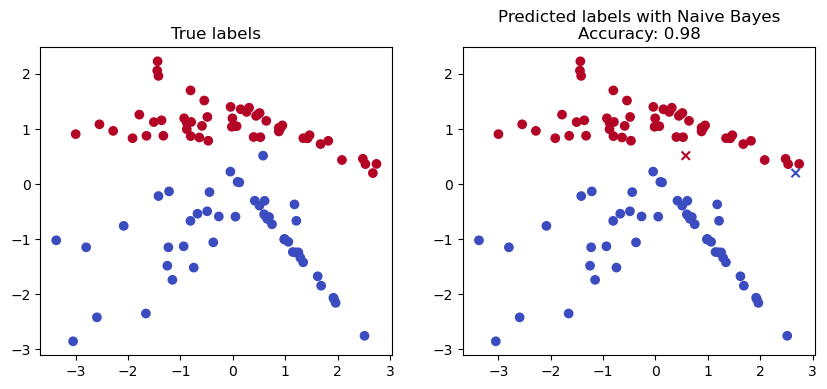

In [71]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X, y)
y_pred = model.predict(X)
acc_score = accuracy_score(y, y_pred)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
# Create a mask for wrong classifications
X_correct = X[y == y_pred]
X_wrong = X[y != y_pred]
ax[1].scatter(X_correct[:, 0], X_correct[:, 1], 
              c=y_pred[y == y_pred], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong[:, 0], X_wrong[:, 1], 
              c=y_pred[y != y_pred], marker='x', cmap='coolwarm', label='Wrongly classified')
ax[0].set_title('True labels')
ax[1].set_title(f'Predicted labels with Naive Bayes\nAccuracy: {acc_score}')
plt.show()

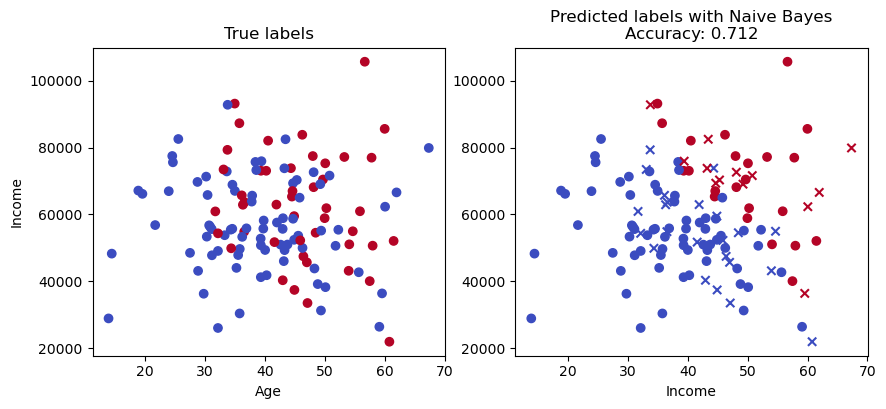

In [72]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_test['age'], X_test['income'], c=y_test, cmap='coolwarm')
ax[0].set_title('True labels')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Income')
# Create a mask for wrong classifications
X_correct = X_test[y_test == y_pred]
X_wrong = X_test[y_test != y_pred]
ax[1].scatter(X_correct['age'], X_correct['income'], 
              c=y_pred[y_test == y_pred], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong['age'], X_wrong['income'], 
              c=y_pred[y_test != y_pred], marker='x', cmap='coolwarm', label='Wrongly classified')
ax[1].set_xlabel('Age')
ax[1].set_xlabel('Income')
ax[1].set_title(f'Predicted labels with Naive Bayes\nAccuracy: {acc_score}')
plt.show()

#### Logistic Regression

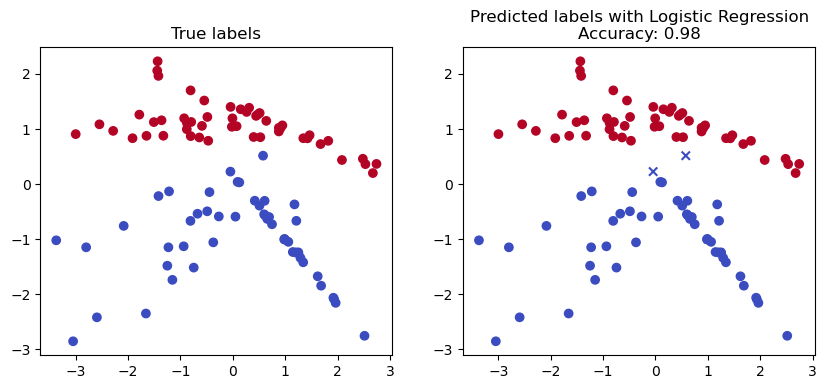

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1, solver='lbfgs')
model.fit(X, y)
y_pred = model.predict(X)
acc_score = accuracy_score(y, y_pred)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
# Create a mask for wrong classifications
X_correct = X[y == y_pred]
X_wrong = X[y != y_pred]
ax[1].scatter(X_correct[:, 0], X_correct[:, 1], 
              c=y_pred[y == y_pred], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong[:, 0], X_wrong[:, 1], 
              c=y_pred[y != y_pred], cmap='coolwarm', marker='x', label='Wrongly classified')
ax[0].set_title('True labels')
ax[1].set_title(f'Predicted labels with Logistic Regression\nAccuracy: {acc_score}')
plt.show()


In [74]:
# Logistic regression with statsmodels.api
# Predict binary outcome 

# Add intercept term
# statsmodels does not add an intercept automatically
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

# Convert coefficients into odds ratios
odds_ratios = np.exp(result.params)
conf_int = result.conf_int()
conf_int.columns = ["Lower 95%", "Upper 95%"]
odds_ratio_table = pd.DataFrame({
    "Coefficient": result.params,
    "Odds Ratio": odds_ratios,
    "P-value": result.pvalues,
    "Lower OR 95%": np.exp(conf_int["Lower 95%"]),
    "Upper OR 95%": np.exp(conf_int["Upper 95%"])
})
print("\nOdds Ratio Table:")
print(odds_ratio_table)

predicted_probabilities = result.predict(X_test_sm)
# Classify as 1 if probability >= 0.5, otherwise 0
predicted_classes = (predicted_probabilities >= 0.5).astype(int)

print("\nAccuracy:")
print(accuracy_score(y_test, predicted_classes))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted_classes))
print("\nClassification Report:")
print(classification_report(y_test, predicted_classes))

Optimization terminated successfully.
         Current function value: 0.580889
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  375
Model:                          Logit   Df Residuals:                      371
Method:                           MLE   Df Model:                            3
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.1244
Time:                        11:16:47   Log-Likelihood:                -217.83
converged:                       True   LL-Null:                       -248.78
Covariance Type:            nonrobust   LLR p-value:                 2.321e-13
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.9048      0.819     -7.213      0.000      -7.509      -4.300
age            0.0658      0.

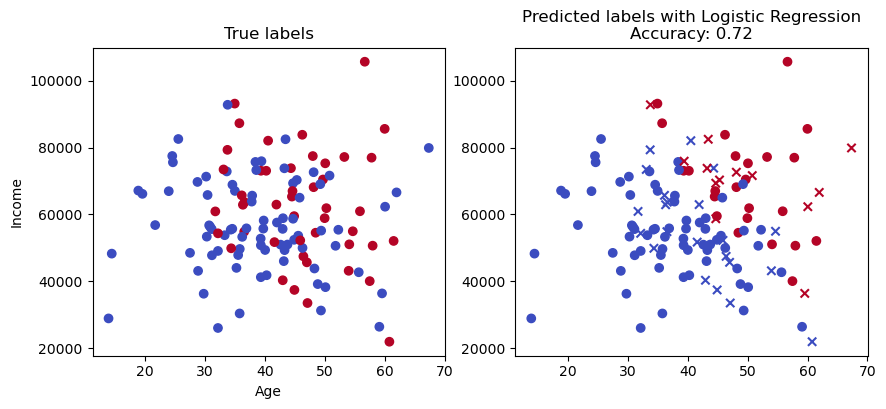

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_test_sm['age'], X_test_sm['income'], c=y_test, cmap='coolwarm')
ax[0].set_title('True labels')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Income')
# Create a mask for wrong classifications
X_correct = X_test_sm[y_test == predicted_classes]
X_wrong = X_test_sm[y_test != predicted_classes]
ax[1].scatter(X_correct['age'], X_correct['income'], 
              c=predicted_classes[y_test == predicted_classes], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong['age'], X_wrong['income'], 
              c=predicted_classes[y_test != predicted_classes], cmap='coolwarm', marker='x', label='Wrongly classified')

ax[1].set_title(f'Predicted labels with Logistic Regression\nAccuracy: {accuracy_score(y_test, predicted_classes)}')
plt.show()

#### Decision Trees

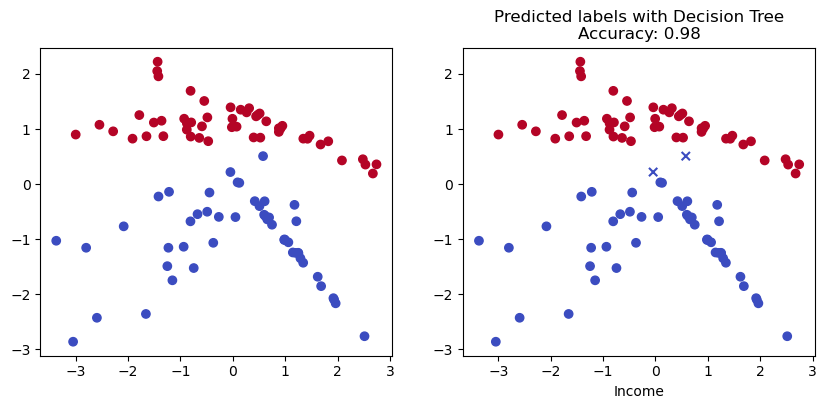

In [76]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1)
model.fit(X, y)
y_pred = model.predict_proba(X)
y_pred = y_pred > 0.5
y_pred = np.array([0 if x[0] == True else 1 for x in y_pred])
acc_score = accuracy_score(y, y_pred)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
# Create a mask for wrong classifications
X_correct = X[y == y_pred]
X_wrong = X[y != y_pred]
ax[1].scatter(X_correct[:, 0], X_correct[:, 1], 
              c=y_pred[y == y_pred], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong[:, 0], X_wrong[:, 1], 
              c=y_pred[y != y_pred], cmap='coolwarm', marker='x', label='Wrongly classified')
ax[1].set_xlabel('Age')
ax[1].set_xlabel('Income')
ax[1].set_title(f'Predicted labels with Decision Tree\nAccuracy: {acc_score}')
plt.show()

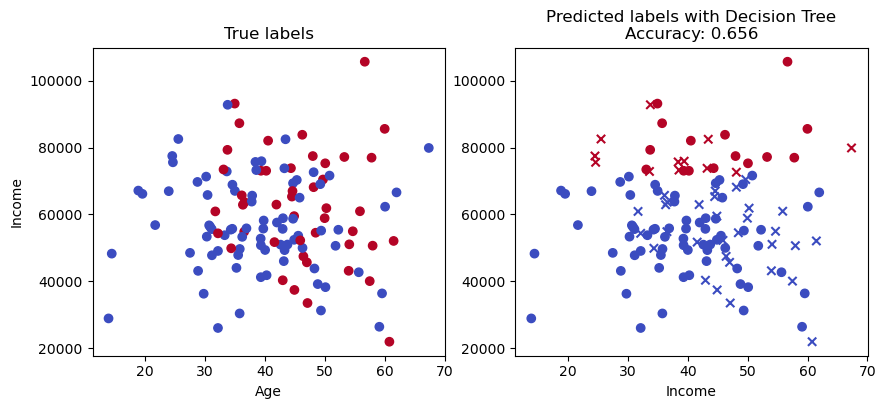

In [78]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)
y_pred = y_pred > 0.5
y_pred = np.array([0 if x[0] == True else 1 for x in y_pred])
acc_score = accuracy_score(y_test, y_pred)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_test['age'], X_test['income'], c=y_test, cmap='coolwarm')
ax[0].set_title('True labels')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Income')
# Create a mask for wrong classifications
X_correct = X_test[y_test == y_pred]
X_wrong = X_test[y_test != y_pred]
ax[1].scatter(X_correct['age'], X_correct['income'], 
              c=y_pred[y_test == y_pred], cmap='coolwarm', label='Correclty classified')
ax[1].scatter(X_wrong['age'], X_wrong['income'], 
              c=y_pred[y_test != y_pred], marker='x', cmap='coolwarm', label='Wrongly classified')
ax[1].set_xlabel('Age')
ax[1].set_xlabel('Income')
ax[1].set_title(f'Predicted labels with Decision Tree\nAccuracy: {acc_score}')
plt.show()